<center><h1>Tong_Stephanie_HW2</h1></center>
<br>
<br>

Name: Stephanie Tong
<br>
Github Username: tongstep
<br>
USC ID: 2614015757

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [2]:
power = pd.read_excel("HW2/CCPP/Folds5x2_pp.xlsx", sheet_name=0)

power.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print("Rows:", power.shape[0])
print("Columns:", power.shape[1])
print(power.shape)


Rows: 9568
Columns: 5
(9568, 5)


There are 9568 rows and 5 columns.
Each row represents an hourly observation.
AT, V, AP, and RH are predictor variables, while PE is the target/response variable.

#### ii. pairwise scatterplots of all the varianbles

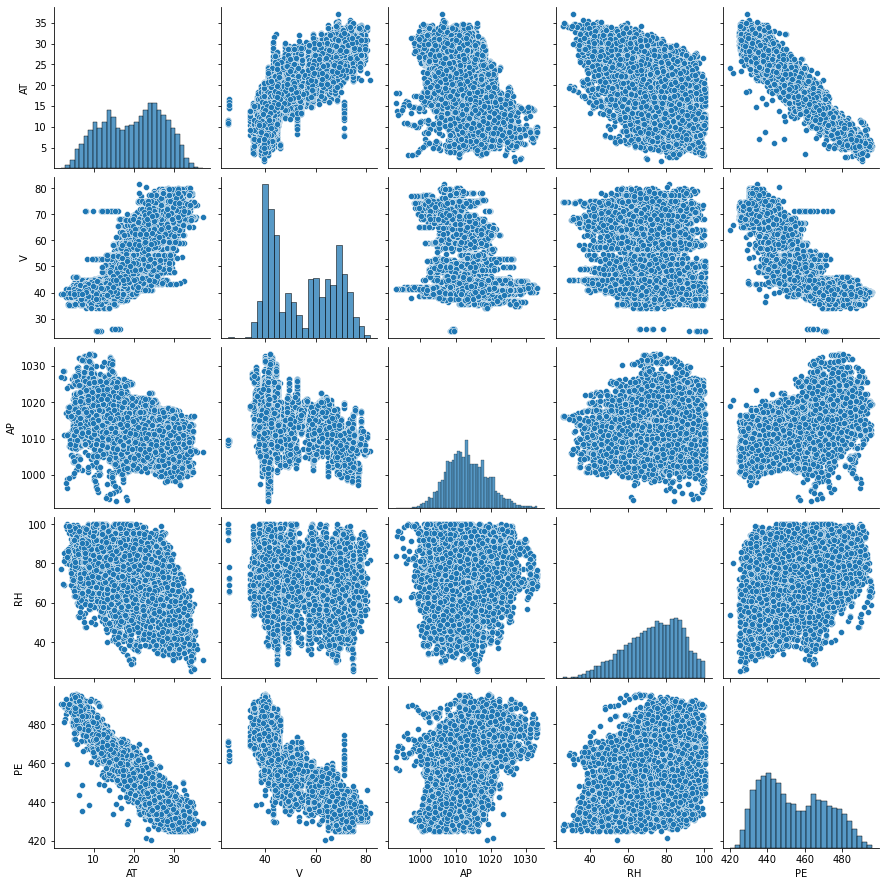

In [4]:
sns.pairplot(power)
plt.show()

The strongest relationship with PE appears to be between AT and PE, which shows a negative relationship. V also appears to have a negative relationship with PE. The relationship between AP and PE and RH and PE appear to be less strong.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
info = pd.DataFrame({
    "Mean": power.mean(),
    "Median": power.median(),
    "Range": power.max() - power.min(),
    "Q1": power.quantile(0.25),
    "Q3": power.quantile(0.75),
    "IQR": power.quantile(0.75) - power.quantile(0.25)
})

info

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [6]:
#AT regression
x_AT = power["AT"]
x_AT_sm = sm.add_constant(x_AT)
model_AT = sm.OLS(power["PE"],x_AT_sm).fit()
print(model_AT.summary())

#V regression
x_V = power["V"]
x_V_sm = sm.add_constant(x_V)
model_V = sm.OLS(power["PE"],x_V_sm).fit()
print(model_V.summary())

#AP regression
x_AP = power["AP"]
x_AP_sm = sm.add_constant(x_AP)
model_AP = sm.OLS(power["PE"],x_AP_sm).fit()
print(model_AP.summary())

#RH regression
x_RH = power["RH"]
x_RH_sm = sm.add_constant(x_RH)
model_RH = sm.OLS(power["PE"],x_RH_sm).fit()
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:39   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

The results show all four predictors are statistically significant with p-values < 0.05. AT and V have negative relationships with PE based on their negative coefficients, while AP and RH have positive relationships based on their positive coefficients. AT has the highest R-squared value at 0.899, then V (0.757), AP (0.269), and RH (0.152). This indicates that AT has the strongest linear relationship with PE.

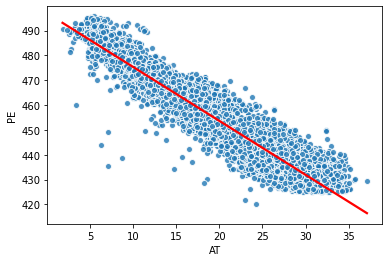

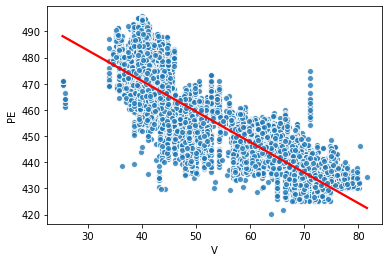

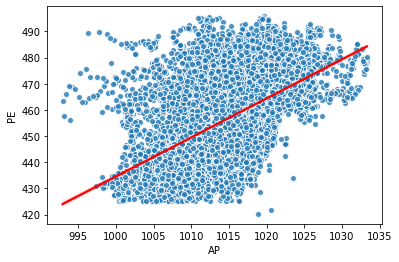

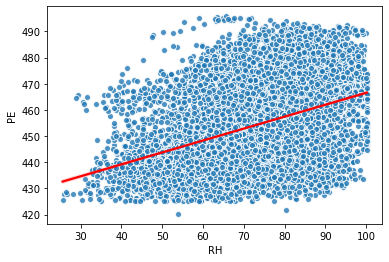

In [7]:
#Create plots to back my assertions
sns.regplot(x=power["AT"], y=power["PE"],
           scatter_kws={"edgecolor":"white"}, line_kws={"color": "red"})
plt.show()

sns.regplot(x=power["V"], y=power["PE"],
           scatter_kws={"edgecolor":"white"}, line_kws={"color": "red"})
plt.show()

sns.regplot(x=power["AP"], y=power["PE"],
           scatter_kws={"edgecolor":"white"}, line_kws={"color": "red"})
plt.show()
                    
sns.regplot(x=power["RH"], y=power["PE"],
           scatter_kws={"edgecolor":"white"}, line_kws={"color": "red"})
plt.show()

The plots show some potential outliers for the regressions. For AT, there are outliers below the regression line. For V, there are outliers below and above the regression line. For AP, there are outliers above and below the regression line. For RH, there are outliers above the regression line.

### (d) Multiple Regression

In [8]:
x = power[["AT", "V", "AP", "RH"]]
x = sm.add_constant(x)

model = sm.OLS(power["PE"], x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:41   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The mutiple regression model has an R-squared of 0.929, meaning the four predictors explain 92.9% of the variation in PE. All four predictors are statistically significant with p-values of 0, which are below the 0.05 significance level. This means all four predictors reject the null hypothesis. AT, V, and Rh have negative coefficients, while AP has a positive coefficient.

### (e) 1c Compare to 1d

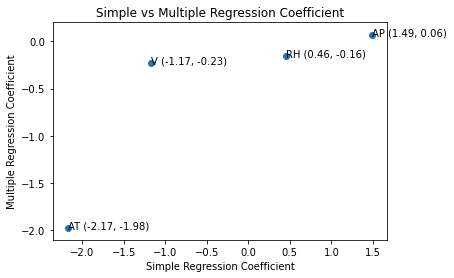

In [9]:
# Compare coefficients from simple and multiple regression

simple = [model_AT.params["AT"], model_V.params["V"], model_AP.params["AP"], model_RH.params["RH"]]
multiple = [model.params["AT"], model.params["V"], model.params["AP"], model.params["RH"]]

plt.scatter(simple, multiple)

plt.text(simple[0], multiple[0], "AT (-2.17, -1.98)")
plt.text(simple[1], multiple[1], "V (-1.17, -0.23)")
plt.text(simple[2], multiple[2], "AP (1.49, 0.06)")
plt.text(simple[3], multiple[3], "RH (0.46, -0.16)")

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficient")

plt.ylim(-2.1,0.2)

plt.show()

The coefficients for AT and V are still negative in both simply and multiple regression model. Their values change, however. The coefficient for AP remains positive but decreases from 1.49 to 0.06. Rh changes from positive coefficient 0.46 in simple regression to negative -0.16 coefficient in multiple regression. The coefficients seem to change when the predictors are considered together, notably for V, AP, and RH.

### (f) Nonlinear Association

In [10]:
# Cubic regressions for AT, V , AP, RH

x_AT_cubic = pd.DataFrame({
    "AT": power["AT"],
    "AT^2": power["AT"]**2,
    "AT^3": power["AT"]**3
})

x_AT_cubic = sm.add_constant(x_AT_cubic)
model_AT_cubic = sm.OLS(power["PE"], x_AT_cubic).fit()
print("AT")
print(model_AT_cubic.summary())



x_V_cubic = pd.DataFrame({
    "V": power["V"],
    "V^2": power["V"]**2,
    "V^3": power["V"]**3
})
                 
x_V_cubic = sm.add_constant(x_V_cubic)
model_V_cubic = sm.OLS(power["PE"], x_V_cubic).fit()
print("V")
print(model_V_cubic.summary())
                 
                 
                 
                 
x_AP_cubic = pd.DataFrame({
    "AP": power["AP"],
    "AP^2": power["AP"]**2,
    "AP^3": power["AP"]**3
})

x_AP_cubic = sm.add_constant(x_AP_cubic)
model_AP_cubic = sm.OLS(power["PE"], x_AP_cubic).fit()
print("AP")
print(model_AP_cubic.summary())

                 

                 
x_RH_cubic = pd.DataFrame({
    "RH": power["RH"],
    "RH^2": power["RH"]**2,
    "RH^3": power["RH"]**3
})

x_RH_cubic = sm.add_constant(x_RH_cubic)
model_RH_cubic = sm.OLS(power["PE"], x_RH_cubic).fit()
print("RH")
print(model_RH_cubic.summary())
                 
    

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:41   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      

The squared and cubed terms for AT, AP, and RH have p-values of 0, which are below the 0.05 significance level. This suggests that these three predictors have nonlinear relationships with PE. For V, the squared term has a p-value of 0.768, while the cubed term has a p-value of 0.014. Therefore, the squared term for V is not statistically significant, but the cubed term is significant. The R-squared values are 0.912 for AT, 0.775 for V, 0.275 for AP, and 0.154 for RH.

### (g) Interactions of Predictors

In [11]:
x_interactions = pd.DataFrame({
    "AT": power["AT"],
    "V": power["V"],
    "AP": power["AP"],
    "RH": power["RH"],
    "AT_V": power["AT"] * power["V"],
    "AT_AP": power["AT"] * power["AP"],
    "AT_RH": power["AT"] * power["RH"],
    "V_AP": power["V"] * power["AP"],
    "V_RH": power["V"] * power["RH"],
    "AP_RH": power["AP"] * power["RH"]
})

x_interactions = sm.add_constant(x_interactions)

model_interactions = sm.OLS(power["PE"], x_interactions).fit()
print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:42   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

The interaction AT-V, AT-RH, V-AP, and AP-RH have p-values below 0.05, showing that these interactions are statistically significant. The AT-AP and V-RH interactions have p-values above 0.05, so they are not statistically significant.

### (h) Improvement

In [12]:
train, test = train_test_split(power, test_size=0.3, random_state=42)

x_train = train[["AT", "V", "AP", "RH"]]
x_train = sm.add_constant(x_train)

x_test = test[["AT", "V", "AP", "RH"]]
x_test = sm.add_constant(x_test)

model_linear = sm.OLS(train["PE"], x_train).fit()

train_pred = model_linear.predict(x_train)
test_pred = model_linear.predict(x_test)

train_mse = mean_squared_error(train["PE"], train_pred)
test_mse = mean_squared_error(test["PE"], test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 20.580839725738695
Testing MSE: 21.23985693822533


In [13]:
#Full model with quadratic terms and interactions
x_train_full = pd.DataFrame({
    "AT": train["AT"],
    "V": train["V"],
    "AP": train["AP"],
    "RH": train["RH"],
    "AT^2": train["AT"]**2,
    "V^2": train["V"]**2,
    "AP^2": train["AP"]**2,
    "RH^2": train["RH"]**2,
    "AT_V": train["AT"] * train["V"],
    "AT_AP": train["AT"] * train["AP"],
    "AT_RH": train["AT"] * train["RH"],
    "V_AP": train["V"] * train["AP"],
    "V_RH": train["V"] * train["RH"],
    "AP_RH": train["AP"] * train["RH"]
})

x_train_full = sm.add_constant(x_train_full)

model_full = sm.OLS(train["PE"], x_train_full).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:42   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

Based on the p-values, V^2, AT×AP, V×AP, and V×RH are not statistically significant at the 0.05 level, so these terms are removed from the model. V is kept because it is part of the significant AT×V interaction.

In [14]:
x_train_reduced = pd.DataFrame({
    "AT": train["AT"],
    "V": train["V"],
    "AP": train["AP"],
    "RH": train["RH"],
    "AT^2": train["AT"]**2,
    "AP^2": train["AP"]**2,
    "RH^2": train["RH"]**2,
    "AT_V": train["AT"] * train["V"],
    "AT_RH": train["AT"] * train["RH"],
    "AP_RH": train["AP"] * train["RH"]
})

x_train_reduced = sm.add_constant(x_train_reduced)

model_reduced = sm.OLS(train["PE"], x_train_reduced).fit()

print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:38:42   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.046e+04   1091.512     -9.581      0.0

In [15]:
# Test reduced model

x_test_reduced = pd.DataFrame({
    "AT": test["AT"],
    "V": test["V"],
    "AP": test["AP"],
    "RH": test["RH"],
    "AT^2": test["AT"]**2,
    "AP^2": test["AP"]**2,
    "RH^2": test["RH"]**2,
    "AT_V": test["AT"] * test["V"],
    "AT_RH": test["AT"] * test["RH"],
    "AP_RH": test["AP"] * test["RH"]
})

x_test_reduced = sm.add_constant(x_test_reduced)

train_pred_reduced = model_reduced.predict(x_train_reduced)
test_pred_reduced = model_reduced.predict(x_test_reduced)

train_mse_reduced = mean_squared_error(train["PE"], train_pred_reduced)
test_mse_reduced = mean_squared_error(test["PE"], test_pred_reduced)

print("Reduced train MSE:", train_mse_reduced)
print("Reduced test MSE:", test_mse_reduced)

Reduced train MSE: 17.91781267118586
Reduced test MSE: 18.694346190802634


In [16]:
# Test full model

x_test_full = pd.DataFrame({
    "AT": test["AT"],
    "V": test["V"],
    "AP": test["AP"],
    "RH": test["RH"],
    "AT^2": test["AT"]**2,
    "V^2": test["V"]**2,
    "AP^2": test["AP"]**2,
    "RH^2": test["RH"]**2,
    "AT_V": test["AT"] * test["V"],
    "AT_AP": test["AT"] * test["AP"],
    "AT_RH": test["AT"] * test["RH"],
    "V_AP": test["V"] * test["AP"],
    "V_RH": test["V"] * test["RH"],
    "AP_RH": test["AP"] * test["RH"]
})

x_test_full = sm.add_constant(x_test_full)

full_test_pred = model_full.predict(x_test_full)
full_test_mse = mean_squared_error(test["PE"], full_test_pred)

print("Full model testing MSE:", full_test_mse)

Full model testing MSE: 18.647312478600643


The linear regression model has a training MSE of 20.58 and a testing MSE of 21.24. After adding quadratic terms and pairwise interactions and removing the insignificant terms based on their p-values, the reduced model has a training MSE of 17.92 and a testing MSE of 18.69. The reduced model has lower training and testing MSEs, showing that adding nonlinearities and interactions improved the performance of the model.

### (i) KNN

In [17]:
#KNN with raw features 

x_train = train[["AT", "V", "AP", "RH"]]
x_test = test[["AT", "V", "AP", "RH"]]

y_train = train["PE"]
y_test = test["PE"]

train_errors = []
test_errors = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    
    train_pred = knn.predict(x_train)
    test_pred = knn.predict(x_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

best_k_train = np.argmin(train_errors) + 1
best_k_test = np.argmin(test_errors) + 1

print("Best k for lowest training MSE:", best_k_train)
print("Best k for lowest testing MSE:", best_k_test)
print("Lowest training MSE:", min(train_errors))
print("Lowest testing MSE:", min(test_errors))

Best k for lowest training MSE: 1
Best k for lowest testing MSE: 5
Lowest training MSE: 0.0
Lowest testing MSE: 15.726819842563568


In [18]:
#KNN with normalized features

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

train_errors_scaled = []
test_errors_scaled = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    
    train_pred = knn.predict(x_train_scaled)
    test_pred = knn.predict(x_test_scaled)
    
    train_errors_scaled.append(mean_squared_error(y_train, train_pred))
    test_errors_scaled.append(mean_squared_error(y_test, test_pred))

best_k_train_scaled = np.argmin(train_errors_scaled) + 1
best_k_test_scaled = np.argmin(test_errors_scaled) + 1

print("Best k for lowest training MSE:", best_k_train_scaled)
print("Best k for lowest testing MSE:", best_k_test_scaled)
print("Lowest training MSE:", min(train_errors_scaled))
print("Lowest testing MSE:", min(test_errors_scaled))

Best k for lowest training MSE: 1
Best k for lowest testing MSE: 4
Lowest training MSE: 0.0
Lowest testing MSE: 14.305669422675024


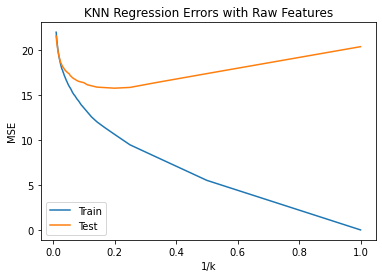

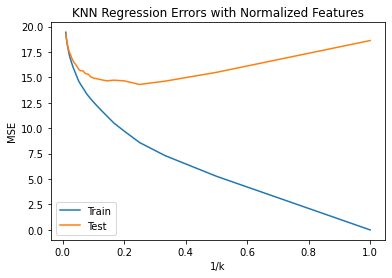

In [19]:
#Plot train and test errors for raw and normalized features

k_values = range(1, 101)

plt.plot([1/k for k in k_values], train_errors, label="Train")
plt.plot([1/k for k in k_values], test_errors, label="Test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression Errors with Raw Features")
plt.legend()
plt.show()

plt.plot([1/k for k in k_values], train_errors_scaled, label="Train")
plt.plot([1/k for k in k_values], test_errors_scaled, label="Test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression Errors with Normalized Features")
plt.legend()
plt.show()

For the raw features, the k value with the lowest testing MSE is 5, with a testing MSE of 15.73. For the normalized features, the k value with the lowest testing MSE is 4, with a testing MSE of 14.31. The normalized features have a lower testing MSE than the raw features.

### (j ) Compare KNN and Linear

In [20]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Full Quadratic + Interactions",
        "Reduced Quadratic + Interactions",
        "KNN Raw Feature",
        "KNN Normalized"
    ],
    "Testing MSE": [
        test_mse,
        full_test_mse,
        test_mse_reduced,
        min(test_errors),
        min(test_errors_scaled)
    ]
})

results

,Model,Testing MSE
0,Linear Regression,21.239857
1,Full Quadratic + Interactions,18.647312
2,Reduced Quadratic + Interactions,18.694346
3,KNN Raw Feature,15.726820
4,KNN Normalized,14.305669


The linear regression model has a testing MSE of 21.24. The full quadratic and interaction model has a lower testing MSE of 18.65, while the reduced model has a testing MSE of 18.69. KNN has lower testing MSEs for both raw and normalized features, with 15.73 for raw features and 14.31 for normalized features. The KNN models have lower testing MSEs than the linear regression models, and normalization lowers the testing MSE for KNN. So KNN Normalized has the smallest test error. Since KNN uses distances between observations, normalization puts all the four predictors at a comparable scale. This prevents those with larger values from having a larger influence on distance calculations. Thus, normalization results in lower testing MSE.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A large sample size gives the model more data to learn from. This makes it more reasonable to use a more flexible method, which can capture more complex relationships and avoid underfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

With many predictors but only a small number of observations, a more inflexible method would be better because a flexible method could overfit the data.

### (c) The relationship between the predictors and response is highly non-linear.

If the relationship is highly non-linear, a more flexible method would be better because it can capture patterns that a simple linear model might miss.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

When the error variance is very high, a less flexible method would be better because a more flexible method could end up fitting the noise in the data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [21]:
data = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

data

,X1,X2,X3,Y
0,0,3,0,Red
1,2,0,0,Red
2,0,1,3,Red
3,0,1,2,Green
4,-1,0,1,Green
5,1,1,1,Red


In [22]:
distances = np.sqrt(data["X1"]**2 + data["X2"]**2 + data["X3"]**2)

distances

0    3.000000
1    2.000000
2    3.162278
3    2.236068
4    1.414214
5    1.732051
dtype: float64

### (b) What is our prediction with K = 1? Why?

Our prediction is Green. We use the response of the closest observation, which is 5 here, to the test point for K=1. Observation 5 has distance 1.41, and its response is Green.

### (c) What is our prediction with K = 3? Why?

Our prediction is Red. The three closest observations are 5, 6, and 2, whose responses are Green, Red, and Red, respectively. Since the majority are Red, the prediction is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

The best value for K would likely be small. A highly non-linear decision boundary requires a more flexible model, and using a small K allows KNN to capture more local patterns in the data.